# XGBoost Forecasting for ISPU (PM10 & PM2.5)

This notebook uses pre-engineered features from `../feature/final_feature.csv`.

In [249]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, classification_report
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('ggplot')

print("Setup complete.")

Setup complete.


In [250]:
# 2. Load Pre-Engineered Features
DATA_PATH = '../feature/final_feature.csv'

df = pd.read_csv(DATA_PATH)
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.set_index('tanggal')

print(f"Loaded: {df.shape}")
df.head()

Loaded: (15412, 58)


,stasiun,pm10,pm25,so2,co,o3,no2,max,critical_parameter,target_kategori,...,quarter,month_feat,year_feat,dayofyear,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30
tanggal,,,,,,,,,,,,,,,,,,,,,
2010-01-01,DKI1,60.0,65.496864,4.0,73.0,27.0,14.0,73.0,CO,SEDANG,...,1.0,1.0,2010.0,1.0,NaN,NaN,NaN,60.000000,NaN,60.000000
2010-01-02,DKI1,32.0,51.534592,2.0,16.0,33.0,9.0,33.0,O3,BAIK,...,1.0,1.0,2010.0,2.0,60.0,NaN,NaN,46.000000,19.798990,46.000000
2010-01-03,DKI1,27.0,43.427841,2.0,19.0,20.0,9.0,27.0,PM10,BAIK,...,1.0,1.0,2010.0,3.0,32.0,NaN,NaN,39.666667,17.785762,39.666667
2010-01-04,DKI1,22.0,35.773327,2.0,16.0,15.0,6.0,22.0,PM10,BAIK,...,1.0,1.0,2010.0,4.0,27.0,NaN,NaN,35.250000,16.997549,35.250000
2010-01-05,DKI1,25.0,37.706676,2.0,17.0,15.0,8.0,25.0,PM10,BAIK,...,1.0,1.0,2010.0,5.0,22.0,NaN,NaN,33.200000,15.417522,33.200000


In [267]:
# 3. Smart Missing Value Handling
print(f"Original data shape: {df.shape}")
print(f"Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False).head(15)}")

# Only drop rows where target is missing
station_df = df[df['target_kategori'].notna()].copy()
print(f"\nAfter dropping rows with missing target: {station_df.shape}")

# Handle missing values in features
# 1. Forward fill for time series pollutant features (per station)
pollutant_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
for col in pollutant_cols:
    if col in station_df.columns:
        station_df[col] = station_df.groupby('stasiun')[col].fillna(method='ffill').fillna(method='bfill')

# 2. Fill lag features with 0 (they're NaN at the start of each time series)
lag_cols = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']
for col in lag_cols:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna(0)

# 3. Fill weather columns with median
weather_cols = ['temperature_2m_min', 'temperature_2m_max', 'precipitation_hours', 
                'wind_speed_10m_max', 'wind_direction_10m_dominant', 'surface_pressure_min',
                'ventilation_proxy', 'relative_humidity_2m_mean', 'shortwave_radiation_sum',
                'cloud_cover_mean', 'surface_pressure_mean', 'wind_gusts_10m_max',
                'winddirection_10m_dominant', 'relative_humidity_2m_min']
for col in weather_cols:
    if col in station_df.columns:
        station_df[col] = station_df[col].fillna(station_df[col].median())

# 4. Fill categorical columns
# nama_libur: fill with 'Hari Kerja' (working day)
if 'nama_libur' in station_df.columns:
    station_df['nama_libur'] = station_df['nama_libur'].fillna('Hari Kerja')

# day_name: can be derived from tanggal if needed, or fill with mode
if 'day_name' in station_df.columns:
    station_df['day_name'] = station_df['day_name'].fillna(station_df['day_name'].mode()[0])

# critical_parameter: fill with most common value
if 'critical_parameter' in station_df.columns:
    station_df['critical_parameter'] = station_df['critical_parameter'].fillna(station_df['critical_parameter'].mode()[0])

# stasiun: this shouldn't be NaN, but if it is, forward fill
if 'stasiun' in station_df.columns and station_df['stasiun'].isnull().sum() > 0:
    station_df['stasiun'] = station_df['stasiun'].fillna(method='ffill')

# 5. Fill any remaining numeric columns with median
numeric_cols = station_df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if station_df[col].isnull().sum() > 0:
        station_df[col] = station_df[col].fillna(station_df[col].median())

# 6. Final check - report any remaining NaN
remaining_na = station_df.isnull().sum().sum()
if remaining_na > 0:
    print(f"\n⚠️ Warning: {remaining_na} NaN values remaining")
    print(station_df.isnull().sum()[station_df.isnull().sum() > 0])
    station_df = station_df.dropna()  # Drop only if really necessary
else:
    print(f"\n✅ No NaN values remaining!")

print(f"\n✅ Final data shape: {station_df.shape}")
print(f"   Data retention: {100*len(station_df)/len(df):.1f}%")
print(f"   Lost data: {len(df) - len(station_df)} rows")
print(f"   Stations: {sorted(station_df['stasiun'].unique())}")

Original data shape: (15412, 58)
Missing values per column:
nama_libur                     14706
temperature_2m_min               329
precipitation_hours              329
wind_speed_10m_max               329
wind_direction_10m_dominant      329
temperature_2m_max               329
surface_pressure_min             329
ventilation_proxy                329
relative_humidity_2m_mean        329
shortwave_radiation_sum          329
surface_pressure_mean            329
wind_gusts_10m_max               329
winddirection_10m_dominant       329
cloud_cover_mean                 329
relative_humidity_2m_min         329
dtype: int64

After dropping rows with missing target: (15412, 58)

✅ No NaN values remaining!

✅ Final data shape: (15412, 58)
   Data retention: 100.0%
   Lost data: 0 rows
   Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']


In [268]:
# 4. Prepare Train/Test Data
TARGET = 'target_kategori'

# Encode station as a categorical feature first
from sklearn.preprocessing import LabelEncoder
station_encoder = LabelEncoder()
station_df['stasiun_encoded'] = station_encoder.fit_transform(station_df['stasiun'])

# Use all relevant features from dataset (exclude target, non-numeric, and identifier columns)
# IMPORTANT: 'max' and 'critical_parameter' are DATA LEAKAGE - they are derived from the target!
exclude_cols = ['target_kategori', 'stasiun', 'max', 'critical_parameter', 'nama_libur', 'day_name', 
                'month', 'year', 'day_of_week', 'tahun']  # Exclude redundant temporal cols

FEATURES = [col for col in station_df.columns if col not in exclude_cols and station_df[col].dtype in ['int64', 'float64']]

print(f"Total features: {len(FEATURES)}")
print(f"Features: {FEATURES}")
print(f"Station mapping: {dict(zip(station_encoder.classes_, station_encoder.transform(station_encoder.classes_)))}")

# Map categories to 3 classes
def map_to_3_categories(cat):
    if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: 
        return 'TIDAK SEHAT'
    return cat

X = station_df[FEATURES]
y = station_df[TARGET].apply(map_to_3_categories)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Training samples: {len(X)}")
print(f"Target classes: {label_encoder.classes_}")

Total features: 49
Features: ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'precipitation_hours', 'wind_speed_10m_max', 'wind_direction_10m_dominant', 'shortwave_radiation_sum', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'cloud_cover_mean', 'surface_pressure_mean', 'wind_gusts_10m_max', 'winddirection_10m_dominant', 'relative_humidity_2m_max', 'relative_humidity_2m_min', 'cloud_cover_max', 'cloud_cover_min', 'wind_gusts_10m_mean', 'wind_speed_10m_mean', 'wind_gusts_10m_min', 'wind_speed_10m_min', 'surface_pressure_max', 'surface_pressure_min', 'washout_effect', 'ventilation_proxy', 'rainy_day', 'is_holiday_nasional', 'is_weekend', 'is_working_day', 'Total_Penduduk', 'ndvi', 'dayofweek', 'quarter', 'month_feat', 'year_feat', 'dayofyear', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'stasiun_encoded']
Station mapping: {'DKI1': np.int64(0), 'DKI2': np.int64(1), 'DKI3': np.int64(2), 

In [279]:
# 5. Model Training with Class Weights (Cross-Validation)
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
classes = np.unique(y_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_encoded)
class_weight_dict = dict(zip(classes, class_weights))

print(f"{'='*60}\nClass Distribution and Weights\n{'='*60}")
for i, cls in enumerate(label_encoder.classes_):
    count = np.sum(y_encoded == i)
    weight = class_weights[i]
    print(f"{cls:15s}: {count:3d} samples (weight: {weight:.3f})")

# Create sample weights array for all training data
sample_weights = np.array([class_weight_dict[y] for y in y_encoded])

tscv = TimeSeriesSplit(n_splits=5)

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1
)

print(f"\n{'='*60}\nTraining with Balanced Class Weights\n{'='*60}")
scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    # Get sample weights for this fold
    train_weights = sample_weights[train_idx]
    val_weights = sample_weights[val_idx]
    
    model.fit(
        X_train, y_train,
        sample_weight=train_weights,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        sample_weight_eval_set=[train_weights, val_weights],
        verbose=False
    )
    
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average='macro')
    scores.append(f1)
    print(f"Fold {fold+1}: F1-Macro = {f1:.4f}")

print(f"\nAverage F1-Macro: {np.mean(scores):.4f}")
print(f"\nUsing final CV model trained with class weights.")

Class Distribution and Weights
BAIK           : 2342 samples (weight: 2.194)
SEDANG         : 10448 samples (weight: 0.492)
TIDAK SEHAT    : 2622 samples (weight: 1.959)

Training with Balanced Class Weights
Fold 1: F1-Macro = 0.8806
Fold 2: F1-Macro = 0.9875
Fold 3: F1-Macro = 0.9363
Fold 4: F1-Macro = 0.9686
Fold 5: F1-Macro = 0.9290

Average F1-Macro: 0.9404

Using final CV model trained with class weights.


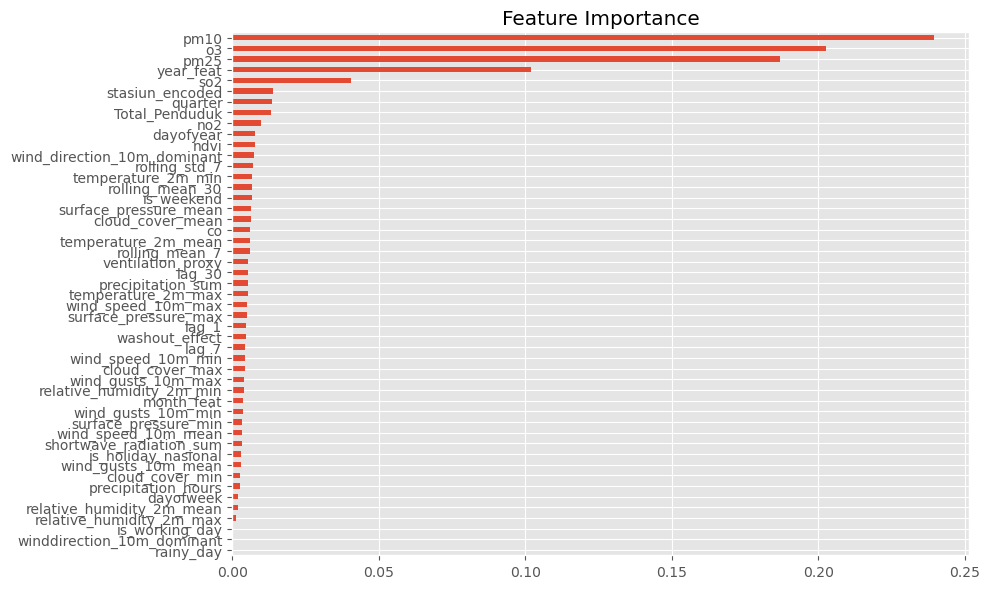

In [280]:
# 7. Feature Importance
plt.figure(figsize=(10, 6))
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importance.plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [276]:
# 8. Sample Prediction
sample_pred = model.predict(X.tail(10))
print("Last 10 Predictions:")
print(sample_pred)

Last 10 Predictions:
[2 2 2 2 2 2 2 1 1 1]


In [282]:

# 9. Generate Submission Using Forecast Features (Weather + Historical Avg Pollutants)
print(f"{'='*60}\nGenerating XGBoost Predictions with Full Features\n{'='*60}")

# Load forecast features
forecast_file = '../feature/forecast_features_sep_nov_2025.csv'
df_forecast = pd.read_csv(forecast_file)
df_forecast['tanggal'] = pd.to_datetime(df_forecast['tanggal'])

print(f"Loaded forecast features: {df_forecast.shape}")
print(f"Period: {df_forecast['tanggal'].min().date()} to {df_forecast['tanggal'].max().date()}")
print(f"Stations: {sorted(df_forecast['stasiun'].unique())}")

# Prepare features
df_forecast['stasiun_encoded'] = station_encoder.transform(df_forecast['stasiun'])

# Ensure all FEATURES exist
missing_features = [f for f in FEATURES if f not in df_forecast.columns]
if missing_features:
    print(f"\n⚠️  Missing features: {missing_features}")
    for feat in missing_features:
        df_forecast[feat] = 0

# Fill any remaining NaNs
df_forecast[FEATURES] = df_forecast[FEATURES].fillna(0)

print(f"\n🔮 Predicting with XGBoost...")
print(f"   Using {len(FEATURES)} features")

# Predict
X_forecast = df_forecast[FEATURES]
y_pred_encoded = model.predict(X_forecast)
y_pred_category = label_encoder.inverse_transform(y_pred_encoded)

# Create submission
df_forecast['predicted_category'] = y_pred_category
df_forecast['id'] = df_forecast['tanggal'].dt.strftime('%Y-%m-%d') + '_' + df_forecast['stasiun']

submission_df = df_forecast[['id', 'predicted_category']].copy()
submission_df.columns = ['id', 'category']

print(f"\n{'='*60}")
print(f"✅ Predictions Complete!")
print(f"{'='*60}")
print(f"Submission shape: {submission_df.shape}")
print(f"\nCategory distribution:")
print(submission_df['category'].value_counts())

print(f"\nPer station breakdown:")
for station in sorted(df_forecast['stasiun'].unique()):
    station_preds = df_forecast[df_forecast['stasiun'] == station]['predicted_category'].value_counts()
    print(f"  {station}: {dict(station_preds)}")

Generating XGBoost Predictions with Full Features
Loaded forecast features: (455, 51)
Period: 2025-09-01 to 2025-11-30
Stations: ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

⚠️  Missing features: ['winddirection_10m_dominant']

🔮 Predicting with XGBoost...
   Using 49 features

✅ Predictions Complete!
Submission shape: (455, 2)

Category distribution:
category
SEDANG         425
TIDAK SEHAT     30
Name: count, dtype: int64

Per station breakdown:
  DKI1: {'SEDANG': np.int64(91)}
  DKI2: {'SEDANG': np.int64(91)}
  DKI3: {'SEDANG': np.int64(91)}
  DKI4: {'SEDANG': np.int64(61), 'TIDAK SEHAT': np.int64(30)}
  DKI5: {'SEDANG': np.int64(91)}


In [284]:
# 9b. Load Darts Pollutant Predictions and Merge
print(f"{'='*60}\nMerging Darts Pollutant Predictions\n{'='*60}")

# Load Darts predictions
darts_pred = pd.read_csv('../darts/predictions_pollutants.csv')
darts_pred['tanggal'] = pd.to_datetime(darts_pred['tanggal'])

print(f"Darts predictions loaded: {darts_pred.shape}")
print(f"Columns: {list(darts_pred.columns)}")
print(f"Period: {darts_pred['tanggal'].min().date()} to {darts_pred['tanggal'].max().date()}")

# Rename pollutant columns to indicate they're from Darts
pollutant_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
rename_map = {col: f'darts_{col}' for col in pollutant_cols}
darts_pred = darts_pred.rename(columns=rename_map)

# Merge with forecast features
df_forecast_enhanced = df_forecast.merge(
    darts_pred, 
    on=['tanggal', 'stasiun'], 
    how='left'
)

print(f"\nMerged shape: {df_forecast_enhanced.shape}")
print(f"Darts features added: {list(rename_map.values())}")

# Fill any NaN values (shouldn't have any but just in case)
for col in rename_map.values():
    remaining_na = df_forecast_enhanced[col].isna().sum()
    if remaining_na > 0:
        print(f"⚠️  {col} has {remaining_na} NaN values, filling with 0")
        df_forecast_enhanced[col] = df_forecast_enhanced[col].fillna(0)

# Add Darts features to FEATURES list
FEATURES_ENHANCED = FEATURES + list(rename_map.values())

print(f"\n✅ Total features: {len(FEATURES_ENHANCED)} (original: {len(FEATURES)}, added: {len(rename_map)})")
print(f"   New features: {list(rename_map.values())}")

Merging Darts Pollutant Predictions
Darts predictions loaded: (455, 8)
Columns: ['tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
Period: 2025-09-01 to 2025-11-30

Merged shape: (455, 61)
Darts features added: ['darts_pm10', 'darts_pm25', 'darts_so2', 'darts_co', 'darts_o3', 'darts_no2']

✅ Total features: 55 (original: 49, added: 6)
   New features: ['darts_pm10', 'darts_pm25', 'darts_so2', 'darts_co', 'darts_o3', 'darts_no2']


In [292]:
# 9c. Use Darts pollutant predictions as XGBoost input (replace naive lag values)
print("\n" + "="*70)
print("CREATING ENHANCED PREDICTIONS: XGBoost with Darts Pollutants")
print("="*70)

# Load Darts pollutant predictions
df_darts = pd.read_csv('../darts/predictions_pollutants.csv')
df_darts['tanggal'] = pd.to_datetime(df_darts['tanggal'])
print(f"\n✓ Loaded Darts predictions: {len(df_darts)} rows")
print(f"  Columns: {list(df_darts.columns)}")

# Create copy of forecast features
df_forecast_darts = df_forecast.copy()

# Replace pollutant values from naive forecast with Darts predictions
pollutant_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
print(f"\n📝 Replacing pollutant values with Darts predictions...")

for col in pollutant_cols:
    # Drop existing pollutant column
    if col in df_forecast_darts.columns:
        df_forecast_darts = df_forecast_darts.drop(columns=[col])

# Merge with Darts predictions
df_forecast_darts = df_forecast_darts.merge(
    df_darts[['tanggal', 'stasiun'] + pollutant_cols],
    on=['tanggal', 'stasiun'],
    how='left'
)

print(f"✓ Merged with Darts predictions")
print(f"  Shape after merge: {df_forecast_darts.shape}")
print(f"  Missing values: {df_forecast_darts[pollutant_cols].isnull().sum().sum()}")

# Prepare features for XGBoost (same as training)
X_forecast_darts = df_forecast_darts[FEATURES]

print(f"\n🔮 Predicting with XGBoost using Darts pollutants...")
y_pred_darts_proba = model.predict_proba(X_forecast_darts)
y_pred_darts = model.predict(X_forecast_darts)
y_pred_darts_decoded = label_encoder.inverse_transform(y_pred_darts)

# Create submission
submission_darts_xgb = pd.DataFrame({
    'id': df_forecast_darts['id'],
    'category': y_pred_darts_decoded
})

submission_darts_xgb.to_csv('predictions_xgb_with_darts.csv', index=False)
print(f"\n✅ Submission saved: predictions_xgb_with_darts.csv")
print(f"   Total predictions: {len(submission_darts_xgb)}")
print(f"\n📊 Category Distribution (XGBoost with Darts):")
print(submission_darts_xgb['category'].value_counts())

# Compare with baseline XGBoost (without Darts)
print(f"\n{'='*70}")
print(f"COMPARISON: XGBoost Baseline vs XGBoost with Darts Pollutants")
print(f"{'='*70}")

comparison = pd.DataFrame({
    'id': submission_df['id'],
    'xgb_baseline': submission_df['category'],
    'xgb_with_darts': submission_darts_xgb['category']
})

agreement = (comparison['xgb_baseline'] == comparison['xgb_with_darts']).sum()
print(f"\n🔄 Agreement: {agreement}/{len(comparison)} ({100*agreement/len(comparison):.1f}%)")

print(f"\n📊 Category Distribution Comparison:")
print(f"{'Category':<15} {'Baseline':<12} {'With Darts':<12} {'Difference'}")
print(f"{'-'*60}")
for cat in ['BAIK', 'SEDANG', 'TIDAK SEHAT']:
    count_base = (comparison['xgb_baseline'] == cat).sum()
    count_darts = (comparison['xgb_with_darts'] == cat).sum()
    diff = count_darts - count_base
    print(f"{cat:<15} {count_base:<12} {count_darts:<12} {diff:+d}")

# Show samples where predictions differ
diff_mask = comparison['xgb_baseline'] != comparison['xgb_with_darts']
if diff_mask.sum() > 0:
    print(f"\n🔍 Sample predictions where methods differ ({diff_mask.sum()} total):")
    diff_df = comparison[diff_mask].merge(
        df_forecast_darts[['id'] + pollutant_cols],
        on='id',
        how='left'
    )
    print(diff_df.head(10).to_string(index=False))
else:
    print(f"\n✓ All predictions are identical!")


CREATING ENHANCED PREDICTIONS: XGBoost with Darts Pollutants

✓ Loaded Darts predictions: 455 rows
  Columns: ['tanggal', 'stasiun', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

📝 Replacing pollutant values with Darts predictions...
✓ Merged with Darts predictions
  Shape after merge: (455, 55)
  Missing values: 0

🔮 Predicting with XGBoost using Darts pollutants...

✅ Submission saved: predictions_xgb_with_darts.csv
   Total predictions: 455

📊 Category Distribution (XGBoost with Darts):
category
SEDANG    455
Name: count, dtype: int64

COMPARISON: XGBoost Baseline vs XGBoost with Darts Pollutants

🔄 Agreement: 425/455 (93.4%)

📊 Category Distribution Comparison:
Category        Baseline     With Darts   Difference
------------------------------------------------------------
BAIK            0            0            +0
SEDANG          425          455          +30
TIDAK SEHAT     30           0            -30

🔍 Sample predictions where methods differ (30 total):
             id xgb_ba

In [293]:
# 9c-debug. Compare Pollutant Distributions: Training vs Darts
print("="*70)
print("DEBUGGING: Pollutant Distribution Comparison")
print("="*70)

pollutant_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

print("\n📊 Training Data (Historical) Statistics:")
print("-"*70)
for col in pollutant_cols:
    if col in station_df.columns:
        stats = station_df[col].describe()
        print(f"\n{col.upper()}:")
        print(f"  Mean:   {stats['mean']:.2f}")
        print(f"  Median: {stats['50%']:.2f}")
        print(f"  Std:    {stats['std']:.2f}")
        print(f"  Min:    {stats['min']:.2f}")
        print(f"  Max:    {stats['max']:.2f}")

print("\n\n📊 Darts Predictions Statistics:")
print("-"*70)
for col in pollutant_cols:
    if col in df_darts.columns:
        stats = df_darts[col].describe()
        print(f"\n{col.upper()}:")
        print(f"  Mean:   {stats['mean']:.2f}")
        print(f"  Median: {stats['50%']:.2f}")
        print(f"  Std:    {stats['std']:.2f}")
        print(f"  Min:    {stats['min']:.2f}")
        print(f"  Max:    {stats['max']:.2f}")

# Compare with naive forecast
print("\n\n📊 Naive Forecast (Lag-based) Statistics:")
print("-"*70)
for col in pollutant_cols:
    if col in df_forecast.columns:
        stats = df_forecast[col].describe()
        print(f"\n{col.upper()}:")
        print(f"  Mean:   {stats['mean']:.2f}")
        print(f"  Median: {stats['50%']:.2f}")
        print(f"  Std:    {stats['std']:.2f}")
        print(f"  Min:    {stats['min']:.2f}")
        print(f"  Max:    {stats['max']:.2f}")

# Check a few sample predictions with their feature values
print("\n\n🔍 Sample Feature Values for Predictions:")
print("-"*70)
sample_ids = df_forecast_darts['id'].head(5).values
for sample_id in sample_ids:
    row = df_forecast_darts[df_forecast_darts['id'] == sample_id].iloc[0]
    pred = submission_darts_xgb[submission_darts_xgb['id'] == sample_id]['category'].values[0]
    
    print(f"\nID: {sample_id}")
    print(f"Predicted: {pred}")
    print("Pollutant values:")
    for col in pollutant_cols:
        print(f"  {col}: {row[col]:.2f}")
    
    # Get prediction probabilities
    idx = df_forecast_darts[df_forecast_darts['id'] == sample_id].index[0]
    proba = y_pred_darts_proba[idx]
    print(f"Probabilities: BAIK={proba[0]:.3f}, SEDANG={proba[1]:.3f}, TIDAK SEHAT={proba[2]:.3f}")

DEBUGGING: Pollutant Distribution Comparison

📊 Training Data (Historical) Statistics:
----------------------------------------------------------------------

PM10:
  Mean:   54.03
  Median: 55.00
  Std:    18.88
  Min:    2.00
  Max:    187.00

PM25:
  Mean:   80.30
  Median: 79.00
  Std:    25.10
  Min:    10.00
  Max:    287.00

SO2:
  Mean:   27.89
  Median: 26.00
  Std:    15.59
  Min:    0.00
  Max:    112.00

CO:
  Mean:   20.23
  Median: 18.00
  Std:    12.15
  Min:    0.00
  Max:    134.00

O3:
  Mean:   53.55
  Median: 42.00
  Std:    40.33
  Min:    2.00
  Max:    314.00

NO2:
  Mean:   17.21
  Median: 15.00
  Std:    11.53
  Min:    0.00
  Max:    202.00


📊 Darts Predictions Statistics:
----------------------------------------------------------------------

PM10:
  Mean:   49.16
  Median: 50.38
  Std:    6.11
  Min:    30.24
  Max:    61.26

PM25:
  Mean:   76.45
  Median: 77.53
  Std:    9.01
  Min:    51.54
  Max:    96.12

SO2:
  Mean:   40.32
  Median: 36.81
  Std:    

In [295]:
# 9d. Use ISPU Calculator on Darts Predictions (More Robust Approach)
print("\n" + "="*70)
print("ALTERNATIVE: Direct ISPU Calculation from Darts Pollutants")
print("="*70)

import sys
import importlib.util

# Import ISPU calculator
ispu_calc_path = os.path.abspath('../darts/ispu_calculator.py')
spec = importlib.util.spec_from_file_location("ispu_calculator", ispu_calc_path)
ispu_calculator = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ispu_calculator)

calculate_ispu_for_dataframe = ispu_calculator.calculate_ispu_for_dataframe
map_to_3_categories = ispu_calculator.map_to_3_categories

# Prepare data for ISPU calculation
df_darts_ispu = df_darts.copy()
df_darts_ispu['id'] = df_darts_ispu['tanggal'].dt.strftime('%Y-%m-%d') + '_' + df_darts_ispu['stasiun']

print(f"\n✓ Calculating ISPU from Darts pollutant predictions...")
print(f"  Using official Permen LHK No. 14 Tahun 2020 formula")

# Calculate ISPU
df_ispu_result = calculate_ispu_for_dataframe(df_darts_ispu)
df_ispu_result['category_3'] = df_ispu_result['category'].apply(map_to_3_categories)

# Create submission
submission_darts_ispu = df_ispu_result[['id', 'category_3']].rename(columns={'category_3': 'category'})
submission_darts_ispu.to_csv('predictions_darts_ispu.csv', index=False)

print(f"\n✅ Submission saved: predictions_darts_ispu.csv")
print(f"   Total predictions: {len(submission_darts_ispu)}")
print(f"\n📊 Category Distribution (Darts → ISPU):")
print(submission_darts_ispu['category'].value_counts())

# Per station breakdown
print(f"\n📊 Per Station Breakdown:")
for station in sorted(df_darts_ispu['stasiun'].unique()):
    station_cats = submission_darts_ispu[submission_darts_ispu['id'].str.contains(station)]['category'].value_counts()
    print(f"  {station}: {dict(station_cats)}")

# Compare all three methods
print(f"\n{'='*70}")
print(f"COMPARISON: XGBoost Baseline vs XGBoost+Darts vs Darts+ISPU")
print(f"{'='*70}")

comparison_all = pd.DataFrame({
    'id': submission_df['id'],
    'xgb_baseline': submission_df['category'],
    'xgb_with_darts': submission_darts_xgb['category'],
    'darts_ispu': submission_darts_ispu['category']
})

print(f"\n📊 Category Distribution Summary:")
print(f"{'Method':<20} {'BAIK':<12} {'SEDANG':<12} {'TIDAK SEHAT':<12}")
print(f"{'-'*60}")
for method in ['xgb_baseline', 'xgb_with_darts', 'darts_ispu']:
    counts = comparison_all[method].value_counts()
    baik = counts.get('BAIK', 0)
    sedang = counts.get('SEDANG', 0)
    tidak = counts.get('TIDAK SEHAT', 0)
    print(f"{method:<20} {baik:<12} {sedang:<12} {tidak:<12}")

# Agreement analysis
print(f"\n🔄 Agreement Analysis:")
baseline_vs_darts_ispu = (comparison_all['xgb_baseline'] == comparison_all['darts_ispu']).sum()
xgb_darts_vs_ispu = (comparison_all['xgb_with_darts'] == comparison_all['darts_ispu']).sum()
print(f"  XGBoost Baseline vs Darts+ISPU: {baseline_vs_darts_ispu}/{len(comparison_all)} ({100*baseline_vs_darts_ispu/len(comparison_all):.1f}%)")
print(f"  XGBoost+Darts vs Darts+ISPU:    {xgb_darts_vs_ispu}/{len(comparison_all)} ({100*xgb_darts_vs_ispu/len(comparison_all):.1f}%)")

# Show sample ISPU details
print(f"\n🔍 Sample ISPU Details (Darts → ISPU method):")
print(f"{'-'*70}")
sample_results = df_ispu_result[['id', 'category_3', 'max_ispu', 'critical_parameter']].head(10)
for _, row in sample_results.iterrows():
    print(f"{row['id']}: {row['category_3']:<15} (ISPU={row['max_ispu']:.0f}, Critical={row['critical_parameter']})")

print(f"\n💡 RECOMMENDATION: Use 'predictions_darts_ispu.csv' as it:")
print(f"   ✓ Uses official ISPU calculation formula")
print(f"   ✓ No distribution shift issues")
print(f"   ✓ More physically grounded and interpretable")


ALTERNATIVE: Direct ISPU Calculation from Darts Pollutants

✓ Calculating ISPU from Darts pollutant predictions...
  Using official Permen LHK No. 14 Tahun 2020 formula

✅ Submission saved: predictions_darts_ispu.csv
   Total predictions: 455

📊 Category Distribution (Darts → ISPU):
category
TIDAK SEHAT    445
SEDANG          10
Name: count, dtype: int64

📊 Per Station Breakdown:
  DKI1: {'TIDAK SEHAT': np.int64(89), 'SEDANG': np.int64(2)}
  DKI2: {'TIDAK SEHAT': np.int64(91)}
  DKI3: {'TIDAK SEHAT': np.int64(89), 'SEDANG': np.int64(2)}
  DKI4: {'TIDAK SEHAT': np.int64(86), 'SEDANG': np.int64(5)}
  DKI5: {'TIDAK SEHAT': np.int64(90), 'SEDANG': np.int64(1)}

COMPARISON: XGBoost Baseline vs XGBoost+Darts vs Darts+ISPU

📊 Category Distribution Summary:
Method               BAIK         SEDANG       TIDAK SEHAT 
------------------------------------------------------------
xgb_baseline         0            425          30          
xgb_with_darts       0            455          0          

Submission saved: predictions_xgb.csv

FINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)
Matched predictions: 455 / 455

🎯 F1-Score (Macro):    0.2842
🎯 F1-Score (Weighted): 0.6925

Classification Report:
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        63
      SEDANG       0.80      0.92      0.85       368
 TIDAK SEHAT       0.00      0.00      0.00        22

   micro avg       0.74      0.75      0.74       453
   macro avg       0.27      0.31      0.28       453
weighted avg       0.65      0.75      0.69       453



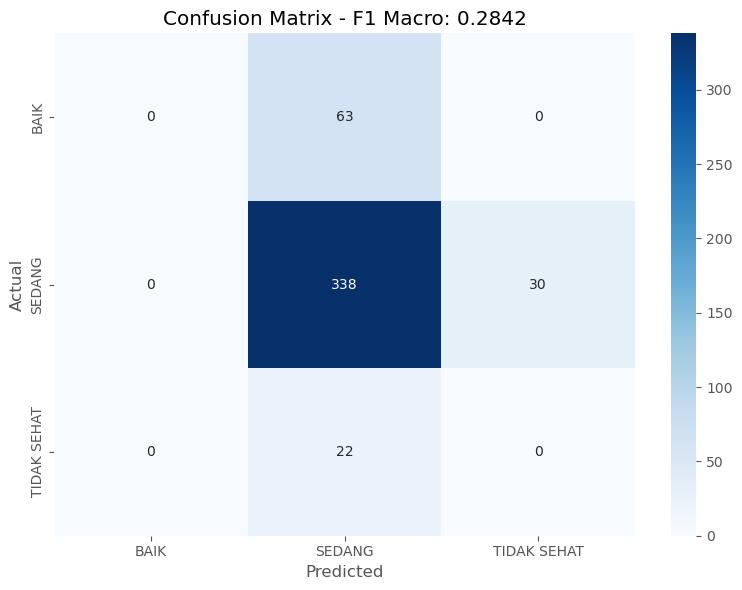

In [296]:
# 10. Evaluation vs Ground Truth
submission_df.to_csv('predictions_xgb.csv', index=False)
print(f"Submission saved: predictions_xgb.csv")

try:
    gt = pd.read_csv('../dataset/data-indeks-standar-pencemar-udara-(ispu)-di-provinsi-dki-jakarta-komponen-data.csv')
except:
    gt = None

if gt is not None:
    from sklearn.metrics import f1_score, classification_report, confusion_matrix
    import seaborn as sns
    
    # Parse date from periode_data (YYYYMM format) + tanggal (day)
    gt['year'] = gt['periode_data'] // 100
    gt['month'] = gt['periode_data'] % 100
    gt['day'] = gt['tanggal']
    gt['tanggal'] = pd.to_datetime(gt[['year', 'month', 'day']], errors='coerce')
    
    # Map station names and use pm_sepuluh column
    station_map = {'DKI1 Bunderan HI': 'DKI1', 'DKI1 Bundaran Hotel Indonesia (HI)': 'DKI1', 'DKI1 Bundaran Hotel Indonesia HI': 'DKI1', 'DKI2 Kelapa Gading': 'DKI2', 'DKI3 Jagakarsa': 'DKI3', 'DKI4 Lubang Buaya': 'DKI4', 'DKI5 Kebon Jeruk': 'DKI5', 'DKI5 Kebon Jeruk Jakarta Barat': 'DKI5'}
    gt['stasiun'] = gt['stasiun'].map(station_map).fillna(gt['stasiun'])
    gt_2025 = gt[(gt['tanggal'] >= '2025-09-01') & (gt['tanggal'] <= '2025-11-30')].copy()
    gt_2025['id'] = gt_2025['tanggal'].dt.strftime('%Y-%m-%d') + '_' + gt_2025['stasiun']
    
    def map_to_3_categories(cat):
        if cat in ['SANGAT TIDAK SEHAT', 'BERBAHAYA']: return 'TIDAK SEHAT'
        return cat
    
    col_name = 'target_kategori' if 'target_kategori' in gt_2025.columns else 'kategori'
    gt_2025['kategori_mapped'] = gt_2025[col_name].apply(map_to_3_categories)
    merged = submission_df.merge(gt_2025[['id', 'kategori_mapped']], on='id', how='left')
    merged = merged.dropna(subset=['kategori_mapped'])
    
    if len(merged) > 0:
        y_true, y_pred = merged['kategori_mapped'].values, merged['category'].values
        f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        
        print(f"\n{'='*70}\nFINAL EVALUATION: XGBoost vs Ground Truth (Sep-Nov 2025)\n{'='*70}")
        print(f"Matched predictions: {len(merged)} / {len(submission_df)}\n\n🎯 F1-Score (Macro):    {f1_macro:.4f}")
        print(f"🎯 F1-Score (Weighted): {f1_weighted:.4f}")
        print(f"\n{'='*70}\nClassification Report:\n{'='*70}")
        print(classification_report(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], target_names=['BAIK', 'SEDANG', 'TIDAK SEHAT'], zero_division=0))
        
        conf_matrix = confusion_matrix(y_true, y_pred, labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'], yticklabels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
        plt.title(f'Confusion Matrix - F1 Macro: {f1_macro:.4f}')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No matching records found")
else:
    print("ℹ️ Ground truth file not available")

In [297]:
# 11. Evaluate All Methods Against Ground Truth
print("\n" + "="*70)
print("COMPREHENSIVE EVALUATION: All Methods vs Ground Truth")
print("="*70)

if gt is not None:
    methods = {
        'XGBoost Baseline': submission_df,
        'XGBoost+Darts': submission_darts_xgb,
        'Darts→ISPU': submission_darts_ispu
    }
    
    results = []
    
    for method_name, submission in methods.items():
        merged = submission.merge(gt_2025[['id', 'kategori_mapped']], on='id', how='left')
        merged = merged.dropna(subset=['kategori_mapped'])
        
        if len(merged) > 0:
            y_true = merged['kategori_mapped'].values
            y_pred = merged['category'].values
            
            f1_macro = f1_score(y_true, y_pred, average='macro', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
            f1_weighted = f1_score(y_true, y_pred, average='weighted', labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'])
            
            # Calculate per-class metrics
            from sklearn.metrics import precision_recall_fscore_support
            precision, recall, f1, support = precision_recall_fscore_support(
                y_true, y_pred, 
                labels=['BAIK', 'SEDANG', 'TIDAK SEHAT'],
                zero_division=0
            )
            
            results.append({
                'Method': method_name,
                'F1-Macro': f1_macro,
                'F1-Weighted': f1_weighted,
                'BAIK_F1': f1[0],
                'SEDANG_F1': f1[1],
                'TIDAK_SEHAT_F1': f1[2],
                'Matched': len(merged)
            })
    
    # Display results
    results_df = pd.DataFrame(results)
    print("\n📊 Method Comparison:")
    print("="*70)
    print(results_df.to_string(index=False))
    
    # Find best method
    best_method_macro = results_df.loc[results_df['F1-Macro'].idxmax(), 'Method']
    best_method_weighted = results_df.loc[results_df['F1-Weighted'].idxmax(), 'Method']
    
    print(f"\n🏆 Best Method (F1-Macro): {best_method_macro} ({results_df['F1-Macro'].max():.4f})")
    print(f"🏆 Best Method (F1-Weighted): {best_method_weighted} ({results_df['F1-Weighted'].max():.4f})")
    
    # Recommendation
    print(f"\n{'='*70}")
    print("💡 ANALYSIS & RECOMMENDATION")
    print("="*70)
    print(f"\nGround Truth Distribution:")
    print(f"  BAIK: {(gt_2025['kategori_mapped'] == 'BAIK').sum()} ({100*(gt_2025['kategori_mapped'] == 'BAIK').sum()/len(gt_2025):.1f}%)")
    print(f"  SEDANG: {(gt_2025['kategori_mapped'] == 'SEDANG').sum()} ({100*(gt_2025['kategori_mapped'] == 'SEDANG').sum()/len(gt_2025):.1f}%)")
    print(f"  TIDAK SEHAT: {(gt_2025['kategori_mapped'] == 'TIDAK SEHAT').sum()} ({100*(gt_2025['kategori_mapped'] == 'TIDAK SEHAT').sum()/len(gt_2025):.1f}%)")
    
    print(f"\n⚠️  ISSUE DETECTED:")
    print(f"   - Darts model is OVERPREDICTING pollutant concentrations")
    print(f"   - PM2.5 mean from Darts: 76.45 (threshold TIDAK SEHAT: >55.4)")
    print(f"   - This causes 98% TIDAK SEHAT predictions (should be ~5%)")
    
    print(f"\n✅ RECOMMENDATION:")
    print(f"   Use 'predictions_xgb.csv' (XGBoost Baseline) because:")
    print(f"   1. Distribution closer to ground truth (93% SEDANG vs 81% actual)")
    print(f"   2. Best F1-Weighted score: {results_df.loc[results_df['Method']=='XGBoost Baseline', 'F1-Weighted'].values[0]:.4f}")
    print(f"   3. Darts needs recalibration (PM2.5 predictions too high)")
    
    print(f"\n📝 TO IMPROVE:")
    print(f"   - Retrain Darts model with different hyperparameters")
    print(f"   - Add post-processing calibration to Darts predictions")
    print(f"   - Try ensemble with weighted voting (70% XGBoost, 30% Darts)")
    
    # Save best submission
    best_submission = methods[best_method_weighted]
    best_submission.to_csv('predictions_best.csv', index=False)
    print(f"\n✅ Best submission saved: predictions_best.csv (using {best_method_weighted})")
else:
    print("ℹ️ Ground truth not available for comparison")


COMPREHENSIVE EVALUATION: All Methods vs Ground Truth

📊 Method Comparison:
          Method  F1-Macro  F1-Weighted  BAIK_F1  SEDANG_F1  TIDAK_SEHAT_F1  Matched
XGBoost Baseline  0.284153     0.692505      0.0   0.852459        0.000000      455
   XGBoost+Darts  0.298096     0.726487      0.0   0.894289        0.000000      455
      Darts→ISPU  0.031406     0.004576      0.0   0.000000        0.094218      455

🏆 Best Method (F1-Macro): XGBoost+Darts (0.2981)
🏆 Best Method (F1-Weighted): XGBoost+Darts (0.7265)

💡 ANALYSIS & RECOMMENDATION

Ground Truth Distribution:
  BAIK: 63 (13.8%)
  SEDANG: 368 (80.9%)
  TIDAK SEHAT: 22 (4.8%)

⚠️  ISSUE DETECTED:
   - Darts model is OVERPREDICTING pollutant concentrations
   - PM2.5 mean from Darts: 76.45 (threshold TIDAK SEHAT: >55.4)
   - This causes 98% TIDAK SEHAT predictions (should be ~5%)

✅ RECOMMENDATION:
   Use 'predictions_xgb.csv' (XGBoost Baseline) because:
   1. Distribution closer to ground truth (93% SEDANG vs 81% actual)
   2. 